{'topic': '莲花', 'poem': '《咏莲》\n碧波潋滟映仙姿，玉立娉婷出水时。\n不向东君争艳色，独留清气满瑶池。\n\n赏析：这首作品以莲花为吟咏对象，通过“碧波潋滟映仙姿”描绘莲花在碧波中的绰约风姿，后以“玉立娉婷”进一步勾勒其亭亭玉立之态。后两句“不向东君争艳色，独留清气满瑶池”，借莲花不争春色、独守清气的品格，寄寓了超然物外、高洁自守的精神追求，语言凝练而意境深远。', 'joke': '关于“莲花”的笑话，这里有几个不同风格的版本，希望能让你会心一笑：\n\n**1. 谐音梗（适合快速冷场）**\n莲花和荷花是好朋友。有一天，荷花突然对莲花说：“我觉得咱们的关系好‘污’啊！”\n莲花吓了一跳：“你、你什么意思？”\n荷花叹了口气说：“因为我们都是‘出淤泥而不染’啊……这泥巴里长大的，能不‘污’吗？”\n\n**2. 职场/内卷梗**\n观音菩萨的莲花座最近总是漏水。\n木吒检查了半天，报告说：“菩萨，是莲花的底盘有个洞。”\n观音皱眉：“那怎么办？”\n木吒说：“世面上新出了个‘卷心莲’，据说又紧又密实，绝不漏水。”\n观音叹气：“算了，现在连莲花座都要‘内卷’了吗？我还是继续用这个漏水的吧，至少它懂‘出淤泥而不染’。”\n\n**3. 植物学家的冷笑话**\n一个植物学家指着池塘对徒弟说：“看，那是睡莲。”\n徒弟问：“老师，为什么它叫睡莲？”\n植物学家答：“因为它晚上合上花瓣睡觉。”\n徒弟恍然大悟：“哦！那莲花是不是因为‘莲’色好看，所以叫‘莲（连）花’？”\n植物学家：“……”\n\n**4. 小学生式的无厘头**\n老师问：“小明，你知道为什么莲花出淤泥而不染吗？”\n小明抢答：“我知道！因为它有洁癖，身上沾了泥巴就去洗澡，所以总是干净的！”\n老师：“那它用什么洗澡呢？”\n小明：“用池塘水啊！洗完再拔出来，当然不染了。”\n全班沉默。\n\n**5. 谐音冷笑话（双关版）**\n问：为什么莲花总是很淡定？\n答：因为它“莲（脸）上不挂相”。\n\n**6. 佛教相关（半开玩笑）**\n佛祖讲法时，莲花座突然打了个嗝。\n弟子们大惊：“佛祖！莲花座成精了？”\n佛祖微笑：“不，它只是最近‘花’生吃多了，有点涨气。”\n弟子：“……”\n佛祖补充：“放心，它还能继续‘莲台’（连台）唱戏。”\n\n希望这些笑话能让你像莲花一样——

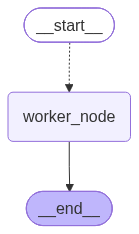

In [7]:

from typing import TypedDict, Literal, Sequence

from IPython.display import display
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Send

load_dotenv(override=True)

CONTENT_TYPES = {
    "poem", "joke", "ci_poem"
}

# 获取模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 1、定义状态
# 1.1 全局状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem: str


# 1.2 私有状态
class WorkerState(TypedDict):
    # content_type 类型是固定的几种
    content_type: Literal["poem", "joke", "ci_poem"]
    prompt: str


# 1.3 输入状态
class InputState(TypedDict):
    topic: str


# 1.4 输出状态
class OutputState(TypedDict):
    ci_poem: str
    poem: str
    joke: str


# 2、定义节点
# 工作节点
def worker_node(state: WorkerState) -> OutputState:
    content_type = state["content_type"]
    prompt = state["prompt"]
    content = model.invoke([HumanMessage(prompt)]).content
    return {
        content_type: content
    }


# 3、定义动态分支的路由
def router(state: InputState) -> Sequence[Send]:
    router_prompt = "请生成关于 {} 的 {}"
    kv = {
        "poem": "七言绝句",
        "joke": "笑话",
        "ci_poem": "中文词"
    }
    topic = state["topic"]

    return [
        Send(
            "worker_node",
            {
                "content_type": content_type,
                "prompt": router_prompt.format(topic, kv[content_type])
            }
        )
        for content_type in CONTENT_TYPES
    ]


# 4、构建图
builder = StateGraph(state_schema=OverAllState, input_schema=InputState, OutputState=OutputState)

builder.add_node("worker_node", worker_node)
#添加条件边
# 由于只有一个节点，pathmap用列表即可
builder.add_conditional_edges(START, router, path_map=["worker_node"])
builder.add_edge("worker_node", END)

graph = builder.compile()
res = graph.invoke({"topic": "莲花"})
print(res)

display(graph)
